# Fleuron Candidate Extraction from the Full Corpus

This notebook applies the Otsu configuration selected in `1_SegmentationBenchmark.ipynb` to every
scan in the corpus, locating possible fleuron regions, saving their bounding boxes, and cropping the
corresponding raw RGB regions for later feature extraction.

Its output is candidate-region extraction, or glyph localisation, not pixel-perfect segmentation.
Connected components provide rectangular crop proposals and may merge fleurons whose ink is
physically connected, which is the principal limitation established by the benchmark.

```text
2_CandidateExtraction.ipynb
        ↓ candidate boxes and raw RGB crops
2_clustering/1_FeatureExtraction.ipynb
        ↓ DINOv2 representations
2_clustering/2_PairBenchmark.ipynb
```

The clustering pipeline currently reads from an earlier extraction (`all_regions_outputs/`) rather
than from this run's output; §7 explains why and quantifies the difference.

## Methodological choices

- Parameters are read from the benchmark configuration rather than selected on the full corpus.
- The extraction is verified box for box against the frozen benchmark output on the held-out scans.
- Both the original and supplementary image collections are processed with the same method.
- Candidate boxes and RGB crops are stored under `1_segmentation_outputs/`.
- The procedure is deterministic and records the configuration and source-image inventory.

---

**Reads** the frozen Otsu configuration and every corpus scan · **Writes** `1_segmentation_outputs/otsu_g3_area40_pad3_v1/`, 40,397 candidates and crops · **Chapter README** §7

## 1. Frozen configuration and output contract

The frozen values are loaded directly from the benchmark: Gaussian size 3, minimum
connected-component area 40 pixels, and 3 pixels of box padding. These were chosen on the
calibration volumes and evaluated once on held-out volumes, so no parameter tuning occurs below, only
application.

In [1]:
import hashlib
import json
import unicodedata
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image
from tqdm.auto import tqdm

RANDOM_SEED = 42

NOTEBOOK_DIR = Path.cwd().resolve()
assert NOTEBOOK_DIR.name == '1_segmentation', 'Run this notebook from its own folder, 1_segmentation/.'
PROJECT_DIR = NOTEBOOK_DIR.parent
BASE_DIR = PROJECT_DIR.parent
SOURCE_DIRS = {
    'original': BASE_DIR / 'Images',
    'suppl': BASE_DIR / 'images suppl',
}
SUPPORTED_EXTENSIONS = {'.jpg', '.jpeg', '.bmp', '.png', '.tif', '.tiff'}

FROZEN_CONFIG_PATH = PROJECT_DIR / 'annotations' / 'benchmark' / 'otsu_selected_config.json'
with FROZEN_CONFIG_PATH.open(encoding='utf-8') as file_handle:
    frozen_record = json.load(file_handle)
assert frozen_record['selection_metric'] == 'micro_f2_iou50'
assert frozen_record['split'] == 'calibration'
assert int(frozen_record['seed']) == RANDOM_SEED

GAUSSIAN_SIZE = int(frozen_record['gaussian_size'])
GAUSSIAN_KERNEL = (GAUSSIAN_SIZE, GAUSSIAN_SIZE)
MIN_COMPONENT_AREA = int(frozen_record['minimum_area'])
BOX_PADDING = int(frozen_record['padding'])
assert (GAUSSIAN_SIZE, MIN_COMPONENT_AREA, BOX_PADDING) == (3, 40, 3)

RUN_ID = f'otsu_g{GAUSSIAN_SIZE}_area{MIN_COMPONENT_AREA}_pad{BOX_PADDING}_v1'
OUTPUT_ROOT = PROJECT_DIR / '1_segmentation_outputs'
OUTPUT_DIR = OUTPUT_ROOT / RUN_ID
CROPS_DIR = OUTPUT_DIR / 'crops'
FIGURES_DIR = OUTPUT_DIR / 'figures'
BOXES_PATH = OUTPUT_DIR / 'candidate_boxes.csv'
MANIFEST_PATH = OUTPUT_DIR / 'crops_manifest.csv'
IMAGE_SUMMARY_PATH = OUTPUT_DIR / 'image_summary.csv'
DATASET_SUMMARY_PATH = OUTPUT_DIR / 'dataset_summary.csv'
RUN_METADATA_PATH = OUTPUT_DIR / 'run_metadata.json'

for source_name, source_dir in SOURCE_DIRS.items():
    assert source_dir.is_dir(), f'Missing source folder: {source_dir}'
    print(f'Source [{source_name:8}] : {source_dir}')
print('Frozen configuration :', {
    'gaussian_size': GAUSSIAN_SIZE,
    'minimum_area': MIN_COMPONENT_AREA,
    'padding': BOX_PADDING,
})
print('Output directory      :', OUTPUT_DIR)


Source [original] : <project>/../Images
Source [suppl   ] : <project>/../images suppl
Frozen configuration : {'gaussian_size': 3, 'minimum_area': 40, 'padding': 3}
Output directory      : <project>/1_segmentation_outputs/otsu_g3_area40_pad3_v1


## 2. Build the source-image inventory

Hidden files and AppleDouble sidecars are excluded, and Unicode names are normalised to NFC. If two
images shared a stem the crop folders would become ambiguous, so that condition halts the notebook
rather than being resolved by guesswork.

The corpus is identified by the SHA-256 content digest of every image together with its path and
size, and that identity is stored alongside the method parameters in the run metadata, so a stale
run cannot be reused silently after the corpus changes. Identifying the corpus by content rather
than by file timestamps also means that copying or restoring the images, which alters their
timestamps but not the data, does not invalidate a valid run. Bookkeeping that cannot affect the
result, namely the notebook's own filename, the run identifier and the path of the frozen configuration, is
recorded as provenance and kept out of that identity. The identity does not currently include a
hash of the implementation, so archival reproduction also requires preserving the code version.

In [2]:
def normalise_name(value: str) -> str:
    return unicodedata.normalize('NFC', value)


def file_digest(file_path: Path) -> str:
    digest = hashlib.sha256()
    with file_path.open('rb') as file_handle:
        for chunk in iter(lambda: file_handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()


inventory_rows = []
for source_name, source_dir in SOURCE_DIRS.items():
    source_paths = sorted(
        path for path in source_dir.rglob('*')
        if path.is_file()
        and path.suffix.lower() in SUPPORTED_EXTENSIONS
        and not path.name.startswith('.')
    )
    for source_path in source_paths:
        file_stat = source_path.stat()
        inventory_rows.append({
            'source': source_name,
            'source_path': str(source_path),
            'rel_path': str(source_path.relative_to(source_dir)),
            'filename': source_path.name,
            'stem': normalise_name(source_path.stem),
            'file_bytes': int(file_stat.st_size),
            'content_sha256': file_digest(source_path),
        })

source_inventory = pd.DataFrame(inventory_rows).sort_values(
    ['source', 'rel_path']
).reset_index(drop=True)
duplicate_stems = source_inventory[source_inventory.duplicated('stem', keep=False)]
assert duplicate_stems.empty, (
    'Duplicate image stems would overwrite crop folders:\n' +
    duplicate_stems[['source', 'rel_path', 'stem']].to_string(index=False)
)

inventory_signature_text = '\n'.join(
    f"{row.source}|{row.rel_path}|{row.file_bytes}|{row.content_sha256}"
    for row in source_inventory.itertuples(index=False)
)
source_inventory_sha256 = hashlib.sha256(
    inventory_signature_text.encode('utf-8')
).hexdigest()

# what the result depends on: the method, its frozen parameters, and the corpus itself
run_protocol = {
    'method': 'grayscale_minmax_gaussian_otsu_connected_components',
    'connectivity': 8,
    'gaussian_size': GAUSSIAN_SIZE,
    'minimum_component_area': MIN_COMPONENT_AREA,
    'box_padding': BOX_PADDING,
    'source_inventory_sha256': source_inventory_sha256,
    'source_image_count': int(len(source_inventory)),
    'source_counts': {
        key: int(value)
        for key, value in source_inventory.source.value_counts().sort_index().items()
    },
}
# recorded for traceability, but never a reason to consider an existing run invalid
run_provenance = {
    'pipeline': 'fleuron_candidate_extraction',
    'pipeline_version': 1,
    'notebook': '2_CandidateExtraction.ipynb',
    'run_id': RUN_ID,
    'random_seed': RANDOM_SEED,
    'frozen_config': str(FROZEN_CONFIG_PATH.relative_to(PROJECT_DIR)),
}

print(source_inventory.groupby('source').size().rename('images'))
print('Total images:', len(source_inventory))
print('Inventory SHA-256:', source_inventory_sha256)


source
original    455
suppl       158
Name: images, dtype: int64
Total images: 613
Inventory SHA-256: 54b1b96329c3da7339031be03b62f3fbdb308ee34b185c577fcfca4b3107a36e


## 3. Candidate-extraction functions

Each scan is processed independently to keep memory use modest across 613 scans. Every source image
is converted to grayscale, normalised to the full 8-bit range, blurred, and thresholded with
inverted Otsu. Eight-connected foreground components smaller than 40 pixels are discarded, and the
remainder are padded by 3 pixels.

In [3]:
def load_image_rgb(image_path: Path):
    try:
        with Image.open(image_path) as source_image:
            return np.asarray(source_image.convert('RGB'))
    except Exception as error:
        print(f'[SKIP] {image_path.name}: {error}')
        return None


def normalise_min_max(gray_image: np.ndarray) -> np.ndarray:
    minimum = gray_image.min()
    maximum = gray_image.max()
    if maximum == minimum:
        return gray_image.copy()
    normalised = (
        (gray_image.astype(np.float32) - minimum) / (maximum - minimum) * 255
    )
    return normalised.astype(np.uint8)


def segment_scan(rgb_image: np.ndarray) -> np.ndarray:
    gray_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)
    normalised = normalise_min_max(gray_image)
    blurred = cv2.GaussianBlur(normalised, GAUSSIAN_KERNEL, 0)
    _, mask = cv2.threshold(
        blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )
    return mask


def extract_candidates(mask: np.ndarray) -> list[dict]:
    image_height, image_width = mask.shape
    image_area = image_height * image_width
    label_count, _, statistics, _ = cv2.connectedComponentsWithStats(
        mask, connectivity=8
    )
    candidate_rows = []
    for label_index in range(1, label_count):
        component_area = int(statistics[label_index, cv2.CC_STAT_AREA])
        if component_area < MIN_COMPONENT_AREA:
            continue
        left = int(statistics[label_index, cv2.CC_STAT_LEFT])
        top = int(statistics[label_index, cv2.CC_STAT_TOP])
        width = int(statistics[label_index, cv2.CC_STAT_WIDTH])
        height = int(statistics[label_index, cv2.CC_STAT_HEIGHT])
        x_min = max(0, left - BOX_PADDING)
        y_min = max(0, top - BOX_PADDING)
        x_max = min(image_width, left + width + BOX_PADDING)
        y_max = min(image_height, top + height + BOX_PADDING)
        candidate_rows.append({
            'x_min': x_min,
            'y_min': y_min,
            'x_max': x_max,
            'y_max': y_max,
            'width': x_max - x_min,
            'height': y_max - y_min,
            'area': component_area,
            'area_ratio': component_area / image_area,
        })
    return candidate_rows


## 4. Extract candidates and save crops

Crops are saved as raw RGB exactly as they appear on the scan; the binarisation required for DINOv2
is a decision belonging to the feature-extraction stage, not to this one. If existing results already
match the current corpus inventory and configuration, they are loaded instead of re-extracted.

In [4]:
CORE_OUTPUT_PATHS = [
    BOXES_PATH, MANIFEST_PATH, IMAGE_SUMMARY_PATH,
    DATASET_SUMMARY_PATH, RUN_METADATA_PATH,
]

results_are_available = all(path.exists() for path in CORE_OUTPUT_PATHS)
if results_are_available:
    with RUN_METADATA_PATH.open(encoding='utf-8') as file_handle:
        existing_metadata = json.load(file_handle)
    stored_protocol = existing_metadata['protocol']
    protocol_differences = {
        key: {'stored': stored_protocol.get(key), 'current': run_protocol.get(key)}
        for key in set(stored_protocol) | set(run_protocol)
        if stored_protocol.get(key) != run_protocol.get(key)
    }
    assert not protocol_differences, (
        'The existing output was produced from a different corpus or configuration:\n' +
        json.dumps(protocol_differences, indent=2)
    )
    candidate_boxes = pd.read_csv(BOXES_PATH)
    crops_manifest = pd.read_csv(MANIFEST_PATH)
    image_summary = pd.read_csv(IMAGE_SUMMARY_PATH)
    dataset_summary = pd.read_csv(DATASET_SUMMARY_PATH)
    print('Loaded existing results for this corpus and configuration.')
else:
    if OUTPUT_DIR.exists() and any(OUTPUT_DIR.iterdir()):
        raise RuntimeError(
            f'The output directory contains an incomplete run: {OUTPUT_DIR}. '
            'Inspect it or choose a new RUN_ID before rerunning.'
        )
    CROPS_DIR.mkdir(parents=True, exist_ok=False)
    FIGURES_DIR.mkdir(parents=True, exist_ok=False)

    candidate_rows = []
    crop_rows = []
    image_rows = []
    for inventory_row in tqdm(
        source_inventory.itertuples(index=False),
        total=len(source_inventory),
        desc='Extracting and cropping candidates',
    ):
        image_path = Path(inventory_row.source_path)
        rgb_image = load_image_rgb(image_path)
        if rgb_image is None:
            image_rows.append({
                'filename': inventory_row.filename,
                'source': inventory_row.source,
                'rel_path': inventory_row.rel_path,
                'stem': inventory_row.stem,
                'status': 'failed',
                'image_width': np.nan,
                'image_height': np.nan,
                'n_candidates': 0,
            })
            continue

        image_height, image_width = rgb_image.shape[:2]
        candidates = extract_candidates(segment_scan(rgb_image))
        crop_directory = CROPS_DIR / inventory_row.stem
        if candidates:
            crop_directory.mkdir(parents=True, exist_ok=False)

        for candidate_id, candidate in enumerate(candidates):
            common_row = {
                'filename': inventory_row.filename,
                'source': inventory_row.source,
                'rel_path': inventory_row.rel_path,
                'stem': inventory_row.stem,
                'candidate_id': candidate_id,
                'n_candidates': len(candidates),
                **candidate,
                'image_width': image_width,
                'image_height': image_height,
            }
            candidate_rows.append(common_row)
            crop = rgb_image[
                candidate['y_min']:candidate['y_max'],
                candidate['x_min']:candidate['x_max'],
            ]
            assert crop.size > 0
            crop_path = crop_directory / (
                f"{inventory_row.stem}_candidate_{candidate_id:04d}.png"
            )
            Image.fromarray(crop).save(crop_path)
            crop_rows.append({
                **common_row,
                'crop_path': str(crop_path.relative_to(PROJECT_DIR)),
            })

        image_rows.append({
            'filename': inventory_row.filename,
            'source': inventory_row.source,
            'rel_path': inventory_row.rel_path,
            'stem': inventory_row.stem,
            'status': 'processed',
            'image_width': image_width,
            'image_height': image_height,
            'n_candidates': len(candidates),
        })

    candidate_boxes = pd.DataFrame(candidate_rows)
    crops_manifest = pd.DataFrame(crop_rows)
    image_summary = pd.DataFrame(image_rows)

    summary_rows = []
    for source_name in [*SOURCE_DIRS, 'total']:
        image_subset = (
            image_summary if source_name == 'total'
            else image_summary[image_summary.source == source_name]
        )
        box_subset = (
            candidate_boxes if source_name == 'total'
            else candidate_boxes[candidate_boxes.source == source_name]
        )
        summary_rows.append({
            'source': source_name,
            'images_discovered': len(image_subset),
            'images_processed': int((image_subset.status == 'processed').sum()),
            'images_failed': int((image_subset.status == 'failed').sum()),
            'images_with_candidates': int((image_subset.n_candidates > 0).sum()),
            'candidates': len(box_subset),
            'mean_candidates_per_image': float(image_subset.n_candidates.mean()),
            'median_candidates_per_image': float(image_subset.n_candidates.median()),
        })
    dataset_summary = pd.DataFrame(summary_rows)

    candidate_boxes.to_csv(BOXES_PATH, index=False)
    crops_manifest.to_csv(MANIFEST_PATH, index=False)
    image_summary.to_csv(IMAGE_SUMMARY_PATH, index=False)
    dataset_summary.to_csv(DATASET_SUMMARY_PATH, index=False)
    run_metadata = {
        'protocol': run_protocol,
        'provenance': run_provenance,
        'results': {
            'processed_images': int((image_summary.status == 'processed').sum()),
            'failed_images': int((image_summary.status == 'failed').sum()),
            'candidate_boxes': int(len(candidate_boxes)),
            'crops_written': int(len(crops_manifest)),
        },
    }
    with RUN_METADATA_PATH.open('w', encoding='utf-8') as file_handle:
        json.dump(run_metadata, file_handle, indent=2)
    print('Completed the new isolated extraction run.')

display(dataset_summary)


Loaded existing results for this corpus and configuration.


,source,images_discovered,images_processed,images_failed,images_with_candidates,candidates,mean_candidates_per_image,median_candidates_per_image
0,original,455,455,0,455,25939,57.008791,27.0
1,suppl,158,158,0,158,14458,91.506329,47.5
2,total,613,613,0,613,40397,65.900489,32.0


## 5. Validate the output contract

These checks confirm that every crop listed in the manifest exists on disk, that every box lies
inside its image boundaries, that candidate identifiers are unique within a scan, and that per-scan
candidate counts are internally consistent.

In [5]:
assert len(candidate_boxes) == len(crops_manifest)
assert not candidate_boxes.duplicated(
    ['source', 'stem', 'candidate_id']
).any()
assert (candidate_boxes.x_min >= 0).all()
assert (candidate_boxes.y_min >= 0).all()
assert (candidate_boxes.x_max <= candidate_boxes.image_width).all()
assert (candidate_boxes.y_max <= candidate_boxes.image_height).all()
assert (candidate_boxes.x_max > candidate_boxes.x_min).all()
assert (candidate_boxes.y_max > candidate_boxes.y_min).all()
group_sizes = candidate_boxes.groupby(['source', 'stem']).candidate_id.transform('size')
assert (group_sizes == candidate_boxes.n_candidates).all()

missing_crop_paths = [
    crop_path for crop_path in crops_manifest.crop_path
    if not (PROJECT_DIR / crop_path).exists()
]
assert not missing_crop_paths
assert len(image_summary) == len(source_inventory)
assert (image_summary.status == 'processed').all(), (
    'At least one source image failed. Review image_summary.csv.'
)

print(f'Validated {len(candidate_boxes):,} boxes and {len(crops_manifest):,} crops.')
display(candidate_boxes.head())


Validated 40,397 boxes and 40,397 crops.


,filename,source,rel_path,stem,candidate_id,n_candidates,x_min,y_min,x_max,y_max,width,height,area,area_ratio,image_width,image_height
0,"Oxprlava57.t1,163.bmp",original,"Oxprlava57.t1,163.bmp","Oxprlava57.t1,163",0,9,3,3,221,162,218,159,10165,0.076340,495,269
1,"Oxprlava57.t1,163.bmp",original,"Oxprlava57.t1,163.bmp","Oxprlava57.t1,163",1,9,267,9,491,162,224,153,10034,0.075356,495,269
2,"Oxprlava57.t1,163.bmp",original,"Oxprlava57.t1,163.bmp","Oxprlava57.t1,163",2,9,455,19,468,36,13,17,52,0.000391,495,269
3,"Oxprlava57.t1,163.bmp",original,"Oxprlava57.t1,163.bmp","Oxprlava57.t1,163",3,9,250,109,283,152,33,43,512,0.003845,495,269
4,"Oxprlava57.t1,163.bmp",original,"Oxprlava57.t1,163.bmp","Oxprlava57.t1,163",4,9,215,111,243,136,28,25,272,0.002043,495,269


## 6. Equivalence with the benchmarked implementation

The chapter's headline result is only transferable to this corpus run if the two notebooks apply the
same method. The parameters are already shared, since they are read from the same frozen JSON, but
the implementations are separate pieces of code and could drift apart silently.

The check below closes that gap by comparison rather than by assertion in prose. The 30 held-out
evaluation scans are also part of this corpus, so this run has already produced candidates for them.
Those stored boxes are compared against the frozen candidates on which the held-out precision,
recall, and F₂ were measured. An exact match on every box and every component area establishes that
the corpus extraction is the benchmarked method and not merely a method with the same parameters.

In [6]:
BENCHMARK_DIR = PROJECT_DIR / 'annotations' / 'benchmark'
benchmark_manifest = pd.read_csv(BENCHMARK_DIR / 'image_manifest.csv')
frozen_candidates = pd.read_csv(BENCHMARK_DIR / 'otsu_final_evaluation_candidates.csv')

stem_by_source_path = source_inventory.set_index('source_path').stem.to_dict()
source_path_by_task = {
    int(row.task_id): str(BASE_DIR / row.source_rel_path)
    for row in benchmark_manifest.itertuples(index=False)
}
compared_columns = ['x_min', 'y_min', 'x_max', 'y_max', 'component_area']

comparison_rows = []
for task_id, task_candidates in frozen_candidates.groupby('task_id'):
    source_path = source_path_by_task[int(task_id)]
    assert source_path in stem_by_source_path, (
        f'Evaluation scan {source_path} is not part of this corpus run.'
    )
    stem = stem_by_source_path[source_path]
    corpus_boxes = candidate_boxes[candidate_boxes.stem == stem].rename(
        columns={'area': 'component_area'}
    )
    frozen_boxes = (task_candidates[compared_columns]
                    .sort_values(compared_columns).reset_index(drop=True))
    obtained_boxes = (corpus_boxes[compared_columns]
                      .sort_values(compared_columns).reset_index(drop=True))
    comparison_rows.append({
        'task_id': int(task_id),
        'stem': stem,
        'frozen_boxes': len(frozen_boxes),
        'corpus_boxes': len(obtained_boxes),
        'identical': bool(frozen_boxes.equals(obtained_boxes)),
    })

benchmark_equivalence = pd.DataFrame(comparison_rows)
benchmark_equivalence.to_csv(OUTPUT_DIR / 'benchmark_equivalence_check.csv', index=False)
assert len(benchmark_equivalence) == 30, 'Expected the 30 held-out evaluation scans.'
assert benchmark_equivalence.identical.all(), (
    'This run disagrees with the frozen benchmark candidates on:\n' +
    benchmark_equivalence.loc[~benchmark_equivalence.identical].to_string(index=False)
)

print(
    f'{len(benchmark_equivalence)} held-out evaluation scans re-checked: '
    f'{int(benchmark_equivalence.corpus_boxes.sum())} candidate boxes, all identical to the '
    'frozen benchmark output.'
)
display(benchmark_equivalence.head())

30 held-out evaluation scans re-checked: 863 candidate boxes, all identical to the frozen benchmark output.


,task_id,stem,frozen_boxes,corpus_boxes,identical
0,230,dicolosn73.A3.t1.303le,111,111,True
1,231,moœurovi65.nu.t6.268,47,47,True
2,233,imgocr1761_166a,2,2,True
3,234,auj2am1760_014,6,6,True
4,235,licarovi67.nu.27,33,33,True


## 7. Run diagnostics

The first figure shows a deterministic spread of low-, medium-, and high-candidate scans from both
source folders. The second summarises candidate counts, which describe downstream workload rather
than detection accuracy. Both are run diagnostics; the accuracy figures for this method are produced
by the benchmark notebook and stored under `annotations/benchmark/`.

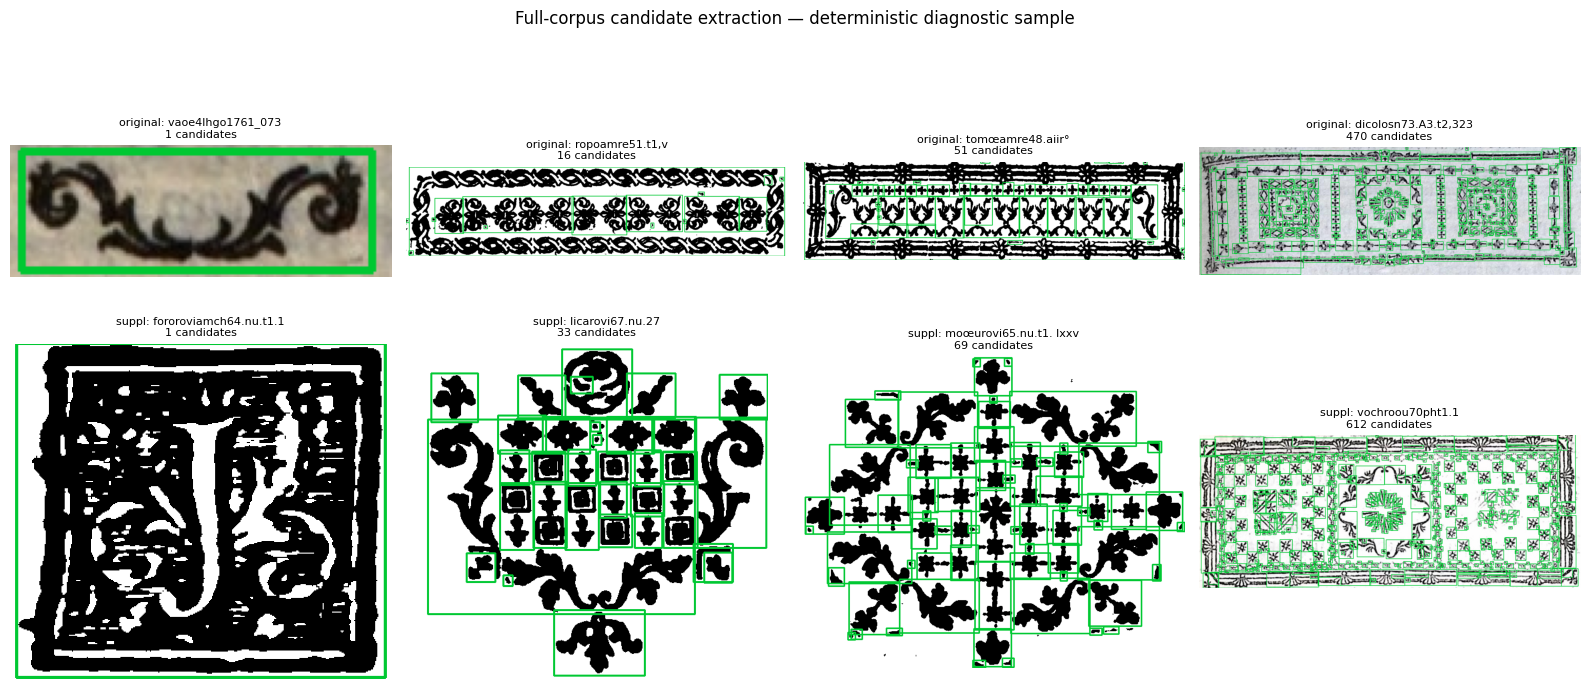

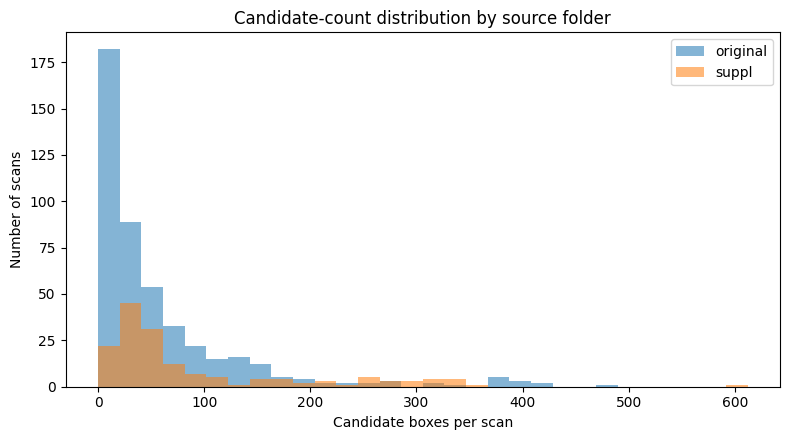

Wrote <project>/1_segmentation_outputs/otsu_g3_area40_pad3_v1/figures/candidate_overlay_sample.png
Wrote <project>/1_segmentation_outputs/otsu_g3_area40_pad3_v1/figures/candidate_count_distribution.png


In [7]:
def draw_boxes(rgb_image: np.ndarray, scan_boxes: pd.DataFrame) -> np.ndarray:
    boxed_image = rgb_image.copy()
    for box_row in scan_boxes.itertuples(index=False):
        cv2.rectangle(
            boxed_image,
            (int(box_row.x_min), int(box_row.y_min)),
            (int(box_row.x_max), int(box_row.y_max)),
            (0, 200, 50),
            2,
        )
    return boxed_image


preview_rows = []
for source_name, source_frame in image_summary.groupby('source'):
    eligible = source_frame[source_frame.n_candidates > 0].sort_values('n_candidates')
    preview_indices = np.unique(
        np.linspace(0, len(eligible) - 1, 4).round().astype(int)
    )
    preview_rows.extend(eligible.iloc[preview_indices].to_dict('records'))
preview_manifest = pd.DataFrame(preview_rows)
preview_manifest.to_csv(FIGURES_DIR / 'preview_scans.csv', index=False)

figure, axes = plt.subplots(2, 4, figsize=(16, 7))
for axis, preview_row in zip(axes.flatten(), preview_manifest.itertuples(index=False)):
    source_path = SOURCE_DIRS[preview_row.source] / preview_row.rel_path
    rgb_image = load_image_rgb(source_path)
    scan_boxes = candidate_boxes[
        (candidate_boxes.source == preview_row.source) &
        (candidate_boxes.stem == preview_row.stem)
    ]
    axis.imshow(draw_boxes(rgb_image, scan_boxes))
    axis.set_title(
        f'{preview_row.source}: {preview_row.stem[:22]}\n'
        f'{preview_row.n_candidates} candidates',
        fontsize=8,
    )
    axis.axis('off')
figure.suptitle(
    'Full-corpus candidate extraction — deterministic diagnostic sample'
)
figure.tight_layout()
preview_path = FIGURES_DIR / 'candidate_overlay_sample.png'
figure.savefig(preview_path, dpi=180, bbox_inches='tight')
plt.show()

figure, axis = plt.subplots(figsize=(8, 4.5))
common_bins = np.linspace(0, image_summary.n_candidates.max(), 31)
for source_name, source_frame in image_summary.groupby('source'):
    axis.hist(
        source_frame.n_candidates, bins=common_bins, alpha=0.55, label=source_name
    )
axis.set_xlabel('Candidate boxes per scan')
axis.set_ylabel('Number of scans')
axis.set_title('Candidate-count distribution by source folder')
axis.legend()
figure.tight_layout()
distribution_path = FIGURES_DIR / 'candidate_count_distribution.png'
figure.savefig(distribution_path, dpi=180, bbox_inches='tight')
plt.show()

print('Wrote', preview_path)
print('Wrote', distribution_path)


## 8. Results and downstream use

This notebook writes only to:

```text
1_segmentation_outputs/otsu_g3_area40_pad3_v1/
├── candidate_boxes.csv
├── crops_manifest.csv
├── image_summary.csv
├── dataset_summary.csv
├── run_metadata.json
├── crops/<scan stem>/*.png
└── figures/
```

The run produced 40,397 candidate boxes and RGB crops across 613 scans. The candidate count measures
how much downstream material is available; it is not an accuracy measure.

This output is not currently what feeds clustering.
`2_clustering/1_FeatureExtraction.ipynb` was built on an earlier extraction
(`all_regions_outputs/`, 30,804 candidates from the pre-benchmark Gaussian 5 / area 80 / pad 3
configuration) before this frozen, formally benchmarked run existed. It was not redirected here,
because doing so would change candidate identities and invalidate roughly 330 human pair-review and
audit labels already collected against the earlier run.

`2_clustering/1_FeatureExtraction.ipynb` §9 measures the practical gap directly rather than
leaving it asserted: **98.8% of the 21,750 crops actually embedded and clustered also have a matching
box in this run's output**, and of the 9,996 candidates this run holds that the earlier extraction
does not, 90.5% fall below the `MIN_SIDE >= 24` filter that clustering already applies. The mismatch
is real but small in effect; the full numbers are in `2_clustering/README.md` §2.